In [51]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from scipy import stats
from sklearn.datasets import make_regression
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, KFold
import matplotlib.pyplot as plt
import seaborn as sns
from torch.nn import MSELoss
from torch.utils.data import DataLoader, TensorDataset, Subset
from torch.utils.tensorboard import SummaryWriter
import statsmodels.api as sm

from sklearn.base import BaseEstimator, RegressorMixin

In [2]:
writer = SummaryWriter(f"runs/LIME")

In [3]:
X, y, coef = make_regression(n_samples=5000, n_features=20, random_state=42, coef=True)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2)

trainval_dataset = TensorDataset(X_train_val, y_train_val)

In [4]:
pd.DataFrame([coef], index=["coef"]).T.sort_values(["coef"], ascending=False)

,coef
1,82.846603
16,78.467952
17,68.280113
14,57.000133
13,48.244771
19,29.506960
8,25.379334
10,19.365118
15,8.889189
18,1.855930


<Axes: ylabel='Count'>

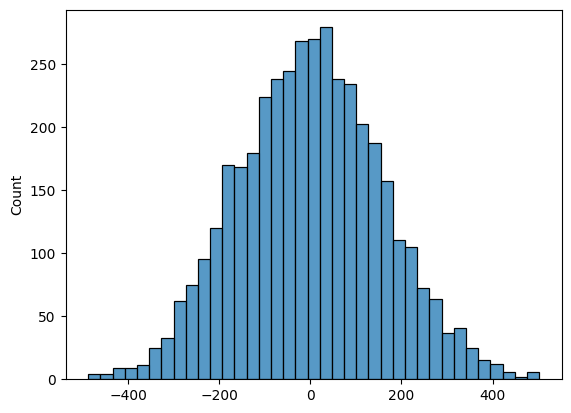

In [5]:
sns.histplot(y_train_val.flatten())

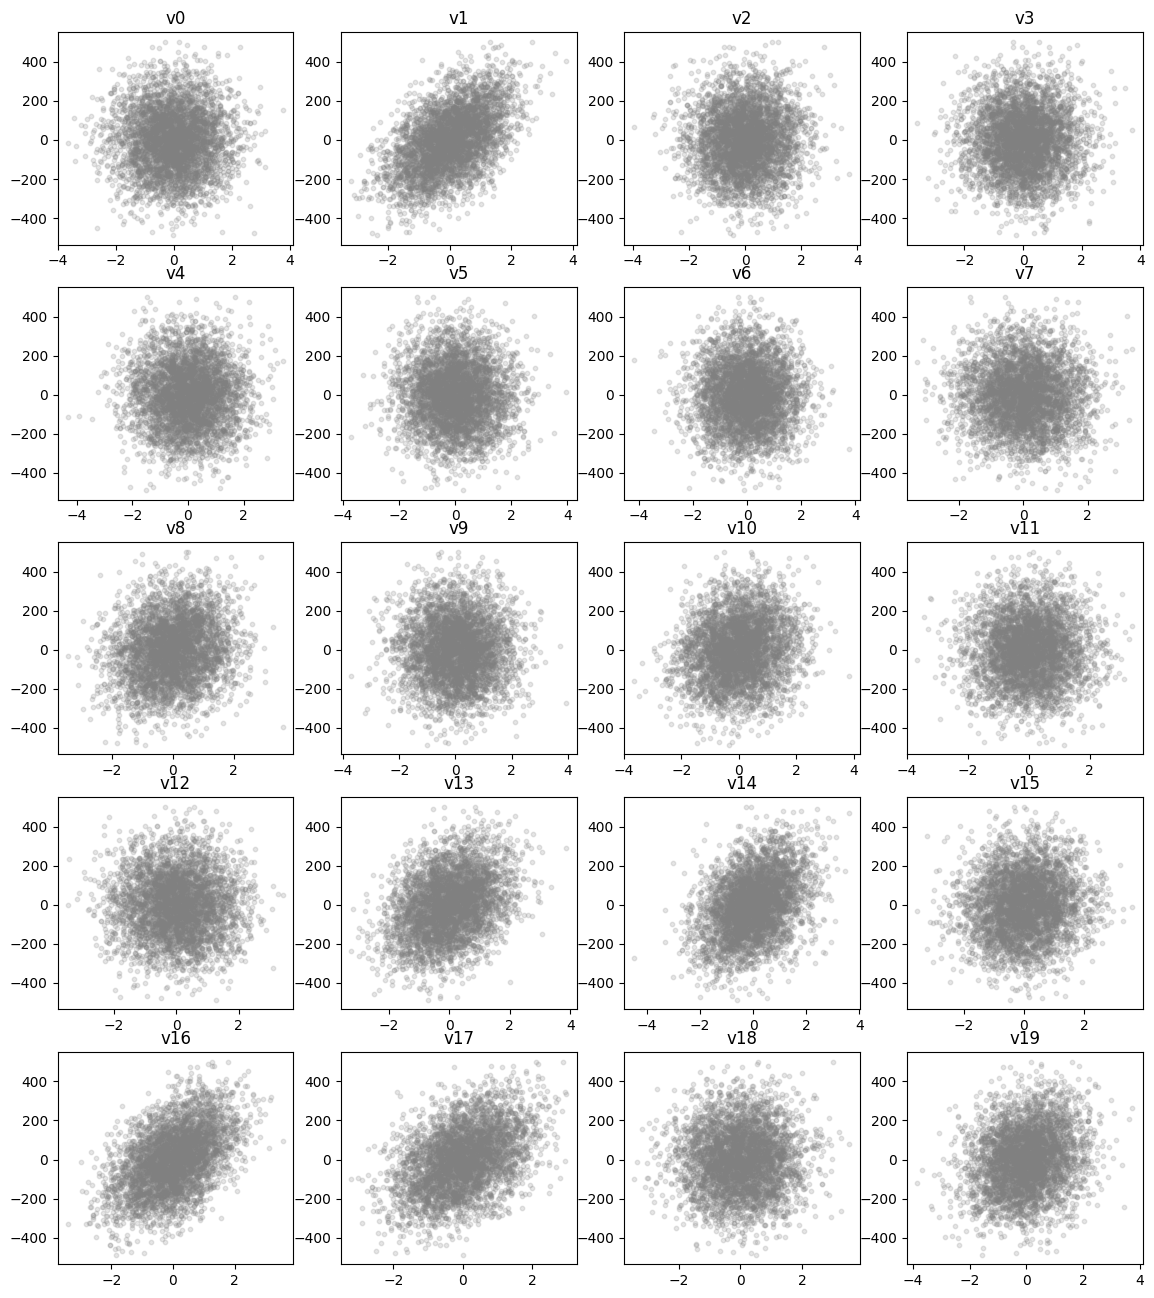

In [6]:
fig, axs = plt.subplots(5, 4, figsize=(14, 16))
axs = axs.flatten()

for feature_idx in range(20):
    axs[feature_idx].scatter(X_train_val[:, feature_idx], y_train_val, alpha=0.2, color='gray', s=10)
    axs[feature_idx].set_title(f"v{feature_idx}")


In [7]:
class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(20, 10),
            nn.ReLU(),
            nn.Linear(10, 1),
        )

        self.train_loss_per_epoch = None
        self.val_loss_per_epoch = None

    def forward(self, x):
        x = self.model(x)
        return x

In [8]:
def train_new_model(fold: int, epochs: int, train_loader: DataLoader, val_loader: DataLoader, save_dir: Path | None):
    model = Model()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    loss_fn = MSELoss()

    print("Fold: ", fold)

    train_loss_per_epoch = np.zeros(epochs)
    val_loss_per_epoch = np.zeros(epochs)
    best_val_loss = 99999999.9

    for epoch in range(epochs):
        total_train_loss = 0.0
        total_val_loss = 0.0

        model.train()
        for data, target in train_loader:
            optimizer.zero_grad()

            output = model(data)
            loss = loss_fn(output, target)

            total_train_loss += loss.item()

            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            for data, target in val_loader:
                output = model(data)
                loss = loss_fn(output, target)
                total_val_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        avg_val_loss = total_val_loss / len(val_loader)
        print(f"{fold=} {epoch=} {avg_train_loss=:.3f} {avg_val_loss=:.3f}")

        train_loss_per_epoch[epoch] = avg_train_loss
        val_loss_per_epoch[epoch] = avg_val_loss

        writer.add_scalar(f"Loss/train/fold{fold}", avg_train_loss, epoch)
        writer.add_scalar(f"Loss/val/fold{fold}", avg_val_loss, epoch)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss

            if save_dir:
                torch.save(model.state_dict(), save_dir / f"fold{fold}.pth")

    model.train_loss_per_epoch = train_loss_per_epoch
    model.val_loss_per_epoch = val_loss_per_epoch

    return model


In [9]:
def train_models_cv5(epochs: int, save_dir: Path | None) -> nn.ModuleList:
    cv = KFold()

    val_losses = 0.0

    models = []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_val, y_train_val)):
        train_loader = DataLoader(Subset(trainval_dataset, train_idx), batch_size=256, shuffle=True)
        val_loader = DataLoader(Subset(trainval_dataset, val_idx), batch_size=256, shuffle=True)
        model = train_new_model(fold, epochs, train_loader, val_loader, save_dir)

        best_val_loss = model.val_loss_per_epoch.min().item()
        val_losses += best_val_loss

        models.append(model)

    return nn.ModuleList(models)

In [10]:
save_dir = Path("checkpoints/best")
save_dir.mkdir(parents=True, exist_ok=True)
models = train_models_cv5(300, save_dir)

Fold:  0
fold=0 epoch=0 avg_train_loss=24973.985 avg_val_loss=23782.120
fold=0 epoch=1 avg_train_loss=24678.589 avg_val_loss=23351.092
fold=0 epoch=2 avg_train_loss=24262.509 avg_val_loss=21130.569
fold=0 epoch=3 avg_train_loss=23511.804 avg_val_loss=21664.245
fold=0 epoch=4 avg_train_loss=22249.765 avg_val_loss=20187.607
fold=0 epoch=5 avg_train_loss=20786.530 avg_val_loss=17931.752
fold=0 epoch=6 avg_train_loss=19042.755 avg_val_loss=17360.006
fold=0 epoch=7 avg_train_loss=17047.465 avg_val_loss=14963.061
fold=0 epoch=8 avg_train_loss=15080.272 avg_val_loss=12911.906
fold=0 epoch=9 avg_train_loss=13204.664 avg_val_loss=12494.749
fold=0 epoch=10 avg_train_loss=11334.947 avg_val_loss=9454.114
fold=0 epoch=11 avg_train_loss=9509.924 avg_val_loss=10430.804
fold=0 epoch=12 avg_train_loss=7949.244 avg_val_loss=7551.301
fold=0 epoch=13 avg_train_loss=6497.773 avg_val_loss=5443.073
fold=0 epoch=14 avg_train_loss=5264.244 avg_val_loss=5435.083
fold=0 epoch=15 avg_train_loss=4218.349 avg_val_l

In [11]:
class MyWrapper(RegressorMixin, BaseEstimator):
    def __init__(self, models: nn.ModuleList):
        self.models = models
        self.models.eval()
        self.is_fitted_ = True

    def fit(self, X, y):
        raise NotImplementedError()

    def predict(self, X):
        with torch.no_grad():
            X = torch.tensor(X)
            y = torch.stack([model(X) for model in self.models]).mean(dim=0)
            return y.numpy()


In [18]:
ensemble = MyWrapper(models)
ind = range(6, 10)
ensemble.predict(X_test[ind]), y_test[ind]
ensemble.score(X_test, y_test)

/tmp/ipykernel_55795/2580477349.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X)


0.9999963045120239

In [19]:
pert_factor = 0.3
num_of_perturbations = 1000
stds = X_train_val.std(dim=0)
X_to_explain = X_test[0]
noise = torch.randn((X_to_explain.shape[0],num_of_perturbations)) * stds.unsqueeze(1)
perturbations = X_to_explain.unsqueeze(1) + noise
perturbations = perturbations.swapaxes(0,1)
outputs = ensemble.predict(perturbations)
perturbations = perturbations.detach().cpu().numpy()
sample = X_to_explain.detach().cpu().numpy()
distances = np.exp(-np.linalg.norm(perturbations - sample, axis=1))

/tmp/ipykernel_55795/2580477349.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X)


In [27]:
outputs.shape, perturbations.shape, distances.shape

((1000, 1), (1000, 20), (1000,))

In [80]:
params_stacked = []
p_val_stacked = []

for X_to_explain in X_test:
    pert_factor = 0.3
    num_of_perturbations = 1000
    stds = X_train_val.std(dim=0)
    noise = torch.randn((X_to_explain.shape[0],num_of_perturbations)) * stds.unsqueeze(1)
    perturbations = X_to_explain.unsqueeze(1) + noise
    perturbations = perturbations.swapaxes(0,1)
    outputs = ensemble.predict(perturbations)
    perturbations = perturbations.detach().cpu().numpy()
    sample = X_to_explain.detach().cpu().numpy()
    distances = np.exp(-np.linalg.norm(perturbations - sample, axis=1))

    lr = sm.WLS(outputs, perturbations, weights=distances)
    lr_results = lr.fit()

    # print(lr_results.summary(xname=[f"v{i}" for i in range(20)]))

    params_stacked.append(lr_results.params)
    p_val_stacked.append(lr_results.pvalues)

params_stacked = np.stack(params_stacked)
p_val_stacked = np.stack(p_val_stacked)

/tmp/ipykernel_55795/2580477349.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X)
/tmp/ipykernel_55795/2580477349.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X)
/tmp/ipykernel_55795/2580477349.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X)
/tmp/ipykernel_55795/2580477349.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTen

In [83]:
avg_params = params_stacked.mean(axis=0)
avg_p_values = p_val_stacked.mean(axis=0)

In [66]:
data = []

r = permutation_importance(ensemble, X_test, y_test, n_repeats=100, random_state=0)

features_p_data = {}

for feature_idx, importance in enumerate(r.importances_mean):
    feature_scores = r.importances[feature_idx]
    t_stat, p_val = stats.ttest_1samp(feature_scores, popmean=0, alternative='greater')

    data.append({
        "importance": importance,
        "p-value": f"{p_val:.4f}",
    })

df_importance = pd.DataFrame(data, index=[f"v{i}" for i in range(20)])

In [84]:
data = np.stack([avg_params, avg_p_values]).T
pd.DataFrame(data, index=[f"v{i}" for i in range(20)], columns=["coef", "p-value"]).sort_values(["coef"], ascending=False)

,coef,p-value
v1,82.830704,0.000000e+00
v16,78.456337,0.000000e+00
v17,68.261040,0.000000e+00
v14,56.993538,0.000000e+00
v13,48.243729,0.000000e+00
v19,29.502930,0.000000e+00
v8,25.378241,0.000000e+00
v10,19.356428,0.000000e+00
v15,8.891809,0.000000e+00
v18,1.846661,6.889358e-256


In [67]:
df_importance.sort_values("importance", ascending=False)

,importance,p-value
v1,5.248654e-01,0.0000
v16,4.619861e-01,0.0000
v17,3.608152e-01,0.0000
v14,2.343599e-01,0.0000
v13,1.791535e-01,0.0000
v19,7.090289e-02,0.0000
v8,4.924137e-02,0.0000
v10,3.020491e-02,0.0000
v15,5.942004e-03,0.0000
v18,2.741623e-04,0.0000
